In [18]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import coherent, destroy
from scipy.special import eval_hermite, factorial

In [2]:
N = 30
alpha = 0.7

psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

In [3]:
a = destroy(N)

In [4]:
X = (a + a.dag()) / np.sqrt(2)

In [9]:
X_plus = (psi_plus.dag() * X * psi_plus).real
X_minus = (psi_minus.dag() * X * psi_minus).real

print("⟨X⟩ for |+α⟩ =", X_plus)
print("⟨X⟩ for |-α⟩ =", X_minus)
print("√2 * α =", np.sqrt(2) * alpha)

⟨X⟩ for |+α⟩ = 0.9899494936611666
⟨X⟩ for |-α⟩ = -0.9899494936611666
√2 * α = 0.9899494936611666


## Plot of probability sendity destribution

In [14]:
N = 40
alpha = 0.7

psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

# Quadrature values
x = np.linspace(-5, 5, 1000)

In [15]:
#Position/quadrature wavefunction <x|n> for the harmonic oscillator.

def fock_wavefunction(n, x):
    normalization = (1/ (np.pi**0.25 * np.sqrt(2**n * factorial(n))))

    return (normalization* eval_hermite(n, x)* np.exp(-x**2 / 2))

In [16]:
#Calculate the quadrature wavefunction psi(x) = <x|psi> from a QuTiP state written in the Fock basis.

def quadrature_wavefunction(state, x):
    N = state.shape[0]
    psi_x = np.zeros_like(x, dtype=complex)

    for n in range(N):
        # Coefficient <n|psi>
        coefficient = state[n, 0]
        # <x|psi> = sum_n <x|n><n|psi>
        psi_x += coefficient * fock_wavefunction(n, x)

    return psi_x

In [20]:
psi_x_plus = quadrature_wavefunction(psi_plus, x)

psi_x_minus = quadrature_wavefunction(psi_minus, x)

P_plus = np.abs(psi_x_plus)**2
P_minus = np.abs(psi_x_minus)**2

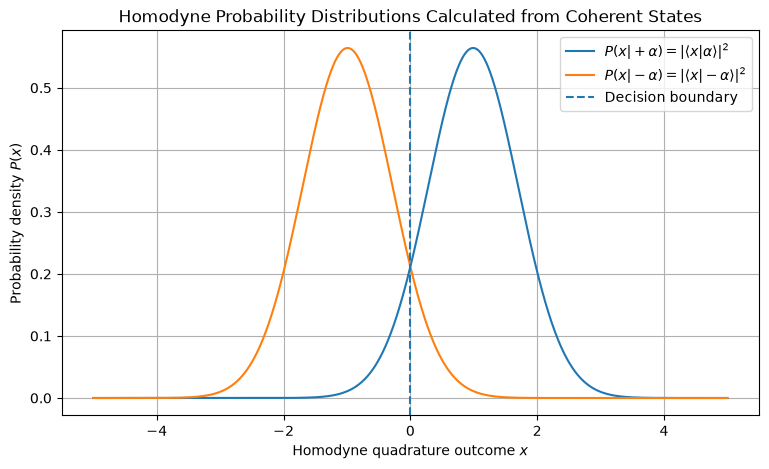

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(x, P_plus, label=r"$P(x|+\alpha)=|\langle x|\alpha\rangle|^2$")
plt.plot(x, P_minus, label=r"$P(x|-\alpha)=|\langle x|-\alpha\rangle|^2$")

plt.axvline(0, linestyle="--", label="Decision boundary")

plt.xlabel(r"Homodyne quadrature outcome $x$")
plt.ylabel(r"Probability density $P(x)$")

plt.title("Homodyne Probability Distributions Calculated from Coherent States")

plt.legend()
plt.grid()
plt.show()

In [22]:
error_plus = np.mean(P_plus < 0)
error_minus = np.mean(P_minus > 0)

P_error_homodyne = 0.5 * (error_plus + error_minus)

print("Homodyne error probability =", P_error_homodyne)

Homodyne error probability = 0.5


In [ ]:
P_hom_theory = 0.5 * erfc(np.sqrt(2) * abs(alpha))
print("Simulated:", P_error_homodyne)
print("Theory:", P_hom_theory)

Simulated: 0.5
Theory: 0.08075665923377107


## Plot P_error as a function of alpha

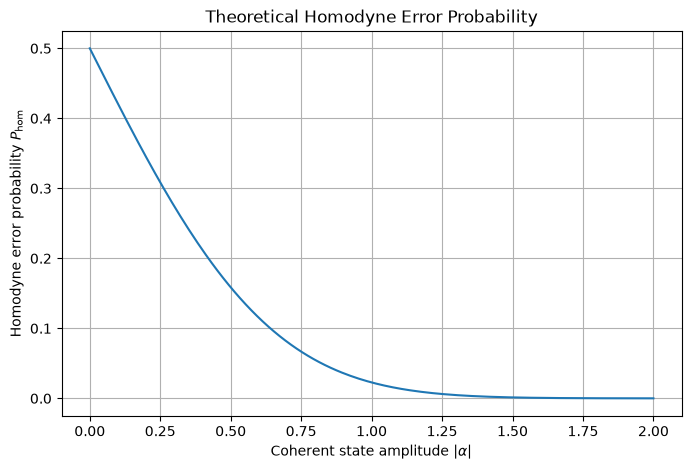

In [25]:
# Range of coherent state amplitudes
alphas = np.linspace(0, 2, 200)

# Theoretical homodyne error probability
P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

# Plot
plt.figure(figsize=(8, 5))

plt.plot(alphas, P_hom_theory)

plt.xlabel(r"Coherent state amplitude $|\alpha|$")
plt.ylabel(r"Homodyne error probability $P_{\mathrm{hom}}$")

plt.title("Theoretical Homodyne Error Probability")
plt.grid(True)
plt.show()